<a href="https://colab.research.google.com/github/dikshabachchani/powerbidashboards/blob/main/sales%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [6]:
data = pd.read_csv("/content/archive (5).zip")

print("Dataset Loaded Successfully")


Dataset Loaded Successfully


In [7]:
print("\nFirst Five Rows")
print(data.head())

print("\nShape of Dataset")
print(data.shape)

print("\nColumn Names")
print(data.columns)

print("\nInformation")
print(data.info())

print("\nMissing Values")
print(data.isnull().sum())


First Five Rows
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Shape of Dataset
(200, 5)

Column Names
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Missing Values
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [8]:
if "Unnamed: 0" in data.columns:
    data.drop("Unnamed: 0", axis=1, inplace=True)

print("\nUpdated Columns")
print(data.columns)


Updated Columns
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


In [9]:
print("\nStatistical Summary")
print(data.describe())



Statistical Summary
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


In [10]:
X = data[["TV", "Radio", "Newspaper"]]

y = data["Sales"]

print("\nInput Features")
print(X.head())

print("\nTarget Variable")
print(y.head())


Input Features
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target Variable
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)


Training Data Shape : (160, 3)
Testing Data Shape : (40, 3)


In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [13]:
predictions = model.predict(X_test)

print("\nPredicted Sales")
print(predictions[:10])



Predicted Sales
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [14]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("\nModel Performance")

print("Mean Absolute Error :", round(mae,2))

print("Mean Squared Error :", round(mse,2))

print("Root Mean Squared Error :", round(rmse,2))

print("R2 Score :", round(r2,2))


Model Performance
Mean Absolute Error : 1.46
Mean Squared Error : 3.17
Root Mean Squared Error : 1.78
R2 Score : 0.9


In [15]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": predictions
})

print("\nComparison")
print(comparison.head(15))


Comparison
    Actual Sales  Predicted Sales
0           16.9        16.408024
1           22.4        20.889882
2           21.4        21.553843
3            7.3        10.608503
4           24.7        22.112373
5           12.6        13.105592
6           22.3        21.057192
7            8.4         7.461010
8           11.5        13.606346
9           14.9        15.155070
10           9.5         9.048320
11           8.7         6.653283
12          11.9        14.345545
13           5.3         8.903493
14          10.3         9.689590


In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Importance")
print(coefficients)



Feature Importance
     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


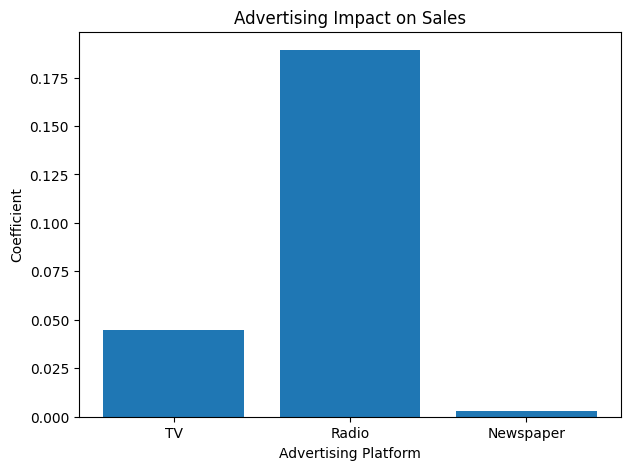

In [17]:
plt.figure(figsize=(7,5))

plt.bar(coefficients["Feature"], coefficients["Coefficient"])

plt.title("Advertising Impact on Sales")

plt.xlabel("Advertising Platform")

plt.ylabel("Coefficient")

plt.show()

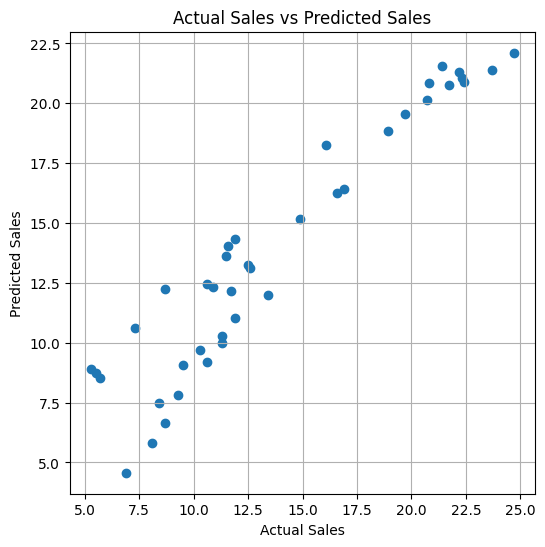

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual Sales vs Predicted Sales")

plt.grid(True)

plt.show()

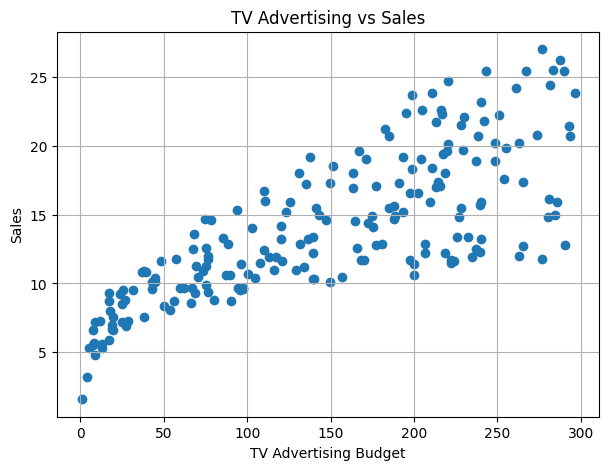

In [19]:
plt.figure(figsize=(7,5))

plt.scatter(data["TV"], data["Sales"])

plt.xlabel("TV Advertising Budget")

plt.ylabel("Sales")

plt.title("TV Advertising vs Sales")

plt.grid(True)

plt.show()


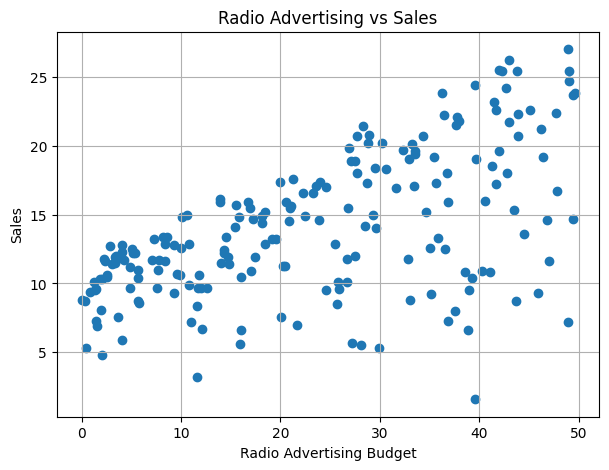

In [20]:
plt.figure(figsize=(7,5))

plt.scatter(data["Radio"], data["Sales"])

plt.xlabel("Radio Advertising Budget")

plt.ylabel("Sales")

plt.title("Radio Advertising vs Sales")

plt.grid(True)

plt.show()

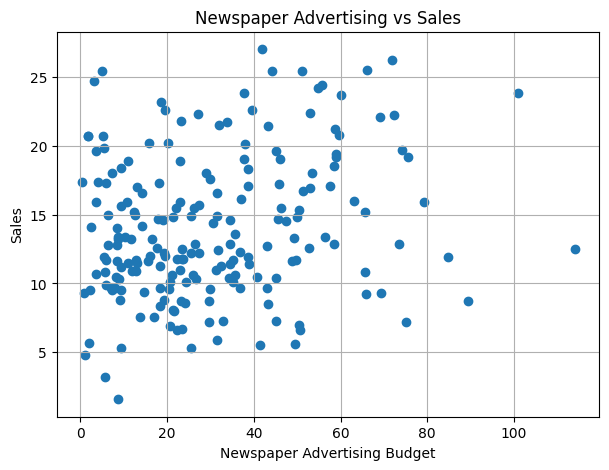

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(data["Newspaper"], data["Sales"])

plt.xlabel("Newspaper Advertising Budget")

plt.ylabel("Sales")

plt.title("Newspaper Advertising vs Sales")

plt.grid(True)

plt.show()


In [22]:
sample = [[230,37,69]]

prediction = model.predict(sample)

print("\nPredicted Sales for New Advertisement")

print(round(prediction[0],2))


Predicted Sales for New Advertisement
20.46


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
print("\nBusiness Insights")

print("TV advertising has the strongest impact on sales.")

print("Radio advertising also contributes positively.")

print("Newspaper advertising has comparatively less influence.")

print("Increasing investment in TV and Radio can improve future sales.")

print("\nProject Completed Successfully")


Business Insights
TV advertising has the strongest impact on sales.
Radio advertising also contributes positively.
Newspaper advertising has comparatively less influence.
Increasing investment in TV and Radio can improve future sales.

Project Completed Successfully
